# Deterministic Brock-Mirman — framework walkthrough

One state, one policy, one Euler equation, no shocks. The smallest possible DEQN problem — but solved end-to-end by the framework, with all of the diagnostic infrastructure a harder model would use.

## Model

A representative agent maximises
$$\max_{\{C_t\}} \sum_t \beta^t \ln C_t \quad\text{s.t.}\quad K_{t+1} + C_t = K_t^{\alpha}$$
with full depreciation $\delta = 1$ (so $K_{t+1} = \text{sav}\cdot K_t^\alpha$) and log utility. The Euler FOC is
$$\frac{1}{C_t} = \beta\,\frac{\alpha\, K_{t+1}^{\alpha-1}}{C_{t+1}}.$$

## Closed form

Under this calibration the optimal policy is a *constant* savings rate
$$s^\star = \alpha\beta$$
for all $K$ (Brock & Mirman 1972). Equivalently, $K_{t+1}^\star = \alpha\beta\, K_t^\alpha$. This is the oracle we benchmark against.

## What the framework does for us

Below we don't write a training loop, a loss function, a sampler, or a plot aggregator by hand. The framework provides:

- **`ModelSpec`** — the model (state/policy/equations/dynamics/SS/init) declared as data in `src/deqn_jax/models/bm_deterministic/`.
- **`train_from_config(TrainConfig)`** — one call. Handles MC / quadrature expectations when present, rollouts when needed, minibatch sweeps, optimizer dispatch, logging, checkpointing.
- **`deqn_jax.plots.*`** — pure-function plots that consume the returned `history` dict.
- **`ModelSpec.cycle_hook`** — the model declares its own diagnostic plots; the trainer fires the hook at `log_every` intervals. We see mid-training convergence automatically.
- **`initialize_each_episode`** (matching DEQN-MAO upstream) — a config flag that re-samples the batch every cycle, needed for deterministic / strongly-attracting problems.

This notebook also reproduces the diagnostics from the reference TF/Keras notebook: policy overlay, relative Euler errors, LHS/RHS sanity check.

In [1]:
# Notebook setup: rich pytree / array displays.
# treescope (transitive dep of penzai, in dev deps) replaces the default
# repr for JAX arrays and registered pytrees with a collapsible widget
# showing shape, dtype, and stats. Useful for inspecting TrainState,
# the policy network, and residual arrays during a training run.
import treescope

treescope.basic_interactive_setup(autovisualize_arrays=True)

In [2]:
from pathlib import Path

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display

from deqn_jax.config import NetworkConfig, OptimizerConfig, TrainConfig
from deqn_jax.models.bm_deterministic import MODEL, steady_state
from deqn_jax.models.bm_deterministic.equations import definitions
from deqn_jax.plots import plot_loss_curve
from deqn_jax.training.trainer import train_from_config

## 1. Inspect the model

The `ModelSpec` declares everything the framework needs: state and policy names, equations, step function, steady-state solver, initial-state sampler, and policy bounds. The trainer reads from it; we don't plumb individual pieces.

In [3]:
print(f"name      : {MODEL.name}")
print(f"states    : {MODEL.state_names}")
print(f"policies  : {MODEL.policy_names}")
print(f"equations : {MODEL.equation_names}")
print(f"n_shocks  : {MODEL.n_shocks}   # truly deterministic")
print()
for k, v in MODEL.constants.items():
    print(f"  {k:8s} = {v}")

ss, pol = steady_state(MODEL.constants)
alpha = MODEL.constants["alpha"]
beta = MODEL.constants["beta"]
s_star = alpha * beta

print()
print(f"K_ss = {float(ss[0]):.4f}")
print(f"s*   = alpha * beta = {s_star:.4f}")

name      : bm_deterministic
states    : ('k',)
policies  : ('sav_rate',)
equations : ('euler',)
n_shocks  : 0   # truly deterministic

  alpha    = 0.36
  beta     = 0.99
  gamma    = 1.0
  delta    = 1.0

K_ss = 0.1995
s*   = alpha * beta = 0.3564


## 2. Train

The config tells the framework how to run. The knobs below are the ones that matter for a deterministic model:

| knob | value | why |
|---|---|---|
| `episode_length` | 1 | no rollout — one-step "sample and step" |
| `initialize_each_episode` | `True` | redraw batch from `init_state_fn` every cycle (uniform $K$ on $[0.10, 1.00]$) |
| `mc_samples` | 1 | no shocks to integrate over |
| `network.init` | `xavier_uniform` | match Keras' `glorot_uniform` default |
| `warm_start` | `False` | the domain is tiny; L-BFGS anchor is unnecessary |
| `optimizer.lr_schedule` | `cosine` | anneal LR over training; constant Adam bounces around the optimum and produces a visibly non-flat policy on this trivially-simple problem |

For stochastic models the same entry point handles MC/quadrature expectations, multi-step rollouts, warm starts, composite losses, etc. Here we just don't turn those on.

In [4]:
cfg = TrainConfig(
    model="bm_deterministic",
    episodes=20001,
    batch_size=64,
    episode_length=1,
    mc_samples=1,
    n_epochs_per_rollout=1,
    n_minibatches_per_epoch=1,
    initialize_each_episode=True,
    network=NetworkConfig(
        hidden_sizes=(50, 50), activation="relu", init="xavier_uniform"
    ),
    optimizer=OptimizerConfig(
        name="adam", learning_rate=1e-3, lr_schedule="cosine", lr_min_factor=0.01
    ),
    warm_start=False,
    seed=0,
    verbose=False,
)

policy_net, history = train_from_config(cfg)

print(f"Initial loss:  {history['loss'][0]:.3e}")
print(f"Final   loss:  {history['loss'][-1]:.3e}")

Initial loss:  2.586e-01
Final   loss:  2.029e-11


## 3. Loss curve

`history` is the dict returned by `train_from_config`. `deqn_jax.plots.plot_loss_curve` is a pure function of it — same plot you'd get in any other model's notebook.

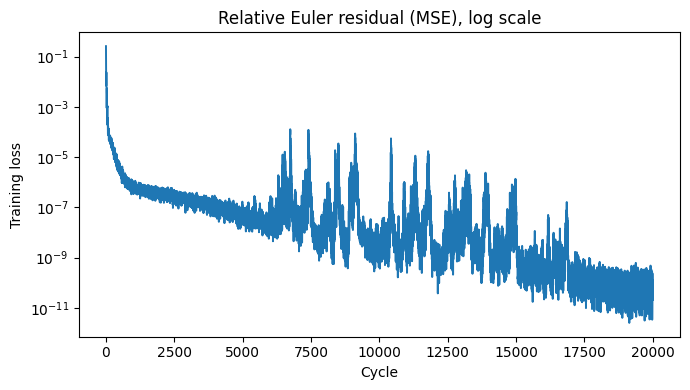

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_loss_curve(history, ax=ax, log_y=True)
ax.set_title("Relative Euler residual (MSE), log scale")
plt.tight_layout()
plt.show()

## 4. Policy vs closed form

The trained network $\mathcal{N}(K)$ should be a flat line at $s^\star = \alpha\beta$ across the whole training domain $K \in [0.10, 1.00]$. Anything else means the network memorised the attractor and extrapolated badly elsewhere.

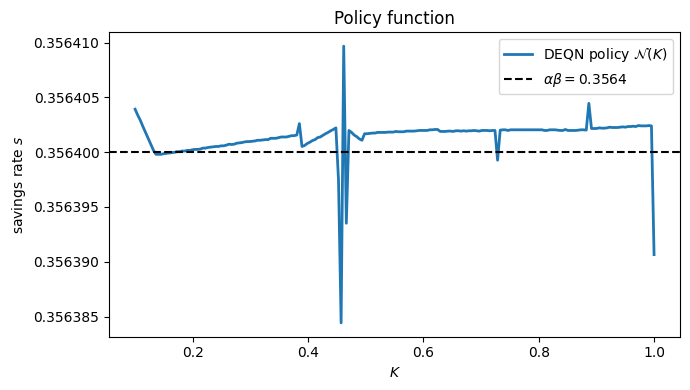

policy error  mean |err|  = 1.763e-06
policy error  max  |err|  = 1.559e-05


In [6]:
k_grid = jnp.linspace(0.10, 1.00, 200)[:, None]
s_pred = np.asarray(policy_net(k_grid))[:, 0]
k_np = np.asarray(k_grid)[:, 0]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_np, s_pred, lw=2, label=r"DEQN policy $\mathcal{N}(K)$")
ax.axhline(s_star, color="k", ls="--", label=rf"$\alpha\beta = {s_star:.4f}$")
ax.set_xlabel("$K$")
ax.set_ylabel("savings rate $s$")
ax.set_title("Policy function")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

err = s_pred - s_star
print(f"policy error  mean |err|  = {np.mean(np.abs(err)):.3e}")
print(f"policy error  max  |err|  = {np.max(np.abs(err)):.3e}")

## 5. Next-period capital vs analytic

Reference-notebook signature plot: $K_{t+1} = s(K) \cdot K^\alpha$ should overlay the analytic curve $\alpha\beta\, K^\alpha$. Same content as the flat-line plot above, rotated into the economics' natural coordinates.

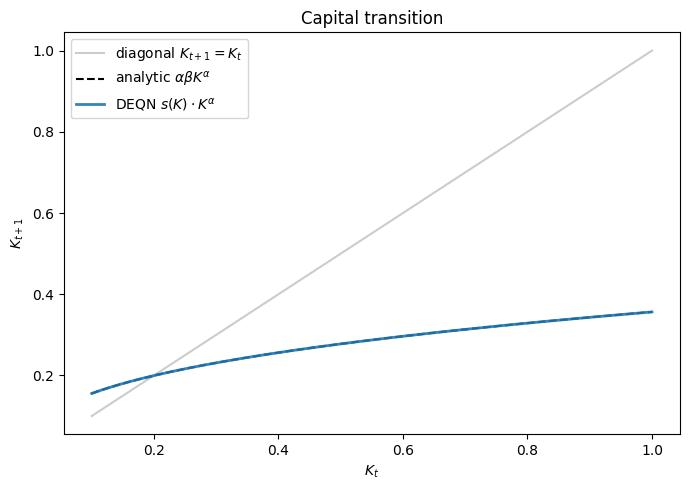

In [7]:
k_next_pred = s_pred * k_np**alpha
k_next_analytic = alpha * beta * k_np**alpha

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(k_np, k_np, color="grey", alpha=0.4, label="diagonal $K_{t+1}=K_t$")
ax.plot(
    k_np,
    k_next_analytic,
    color="k",
    ls="--",
    lw=1.5,
    label=r"analytic $\alpha\beta K^\alpha$",
)
ax.plot(
    k_np, k_next_pred, color="C0", lw=2, alpha=0.9, label=r"DEQN $s(K)\cdot K^\alpha$"
)
ax.set_xlabel("$K_t$")
ax.set_ylabel("$K_{t+1}$")
ax.set_title("Capital transition")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

## 6. Relative Euler error across the domain

The loss is (mean of) this quantity squared. Plotting it against $K$ shows whether the equation is satisfied uniformly or preferentially near the attractor. For a correctly-solved pointwise problem the error should hover around zero everywhere in the sampled range.

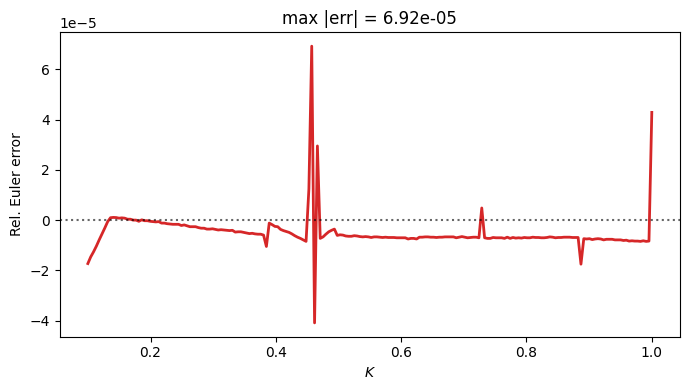

mean |Rel Ee| = 6.549e-06
max  |Rel Ee| = 6.920e-05


In [8]:
from deqn_jax.models.bm_deterministic.dynamics import step as bm_step
from deqn_jax.models.bm_deterministic.equations import equations as bm_equations

states = k_grid  # [200, 1]
policies = policy_net(states)  # [200, 1]
zero_shock = jnp.zeros((states.shape[0], 0))  # n_shocks = 0 -> (batch, 0)
next_states = bm_step(states, policies, zero_shock, MODEL.constants)
next_policies = policy_net(next_states)
resid = bm_equations(states, policies, next_states, next_policies, MODEL.constants)
rel_ee = np.asarray(resid["euler"])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_np, rel_ee, color="C3", lw=2)
ax.axhline(0, color="k", ls=":", alpha=0.6)
ax.set_xlabel("$K$")
ax.set_ylabel("Rel. Euler error")
ax.set_title(f"max |err| = {np.max(np.abs(rel_ee)):.2e}")
plt.tight_layout()
plt.show()

print(f"mean |Rel Ee| = {np.mean(np.abs(rel_ee)):.3e}")
print(f"max  |Rel Ee| = {np.max(np.abs(rel_ee)):.3e}")

## 7. Euler FOC: LHS vs RHS

With log utility the Euler equation is $\tfrac{1}{C_t} = \beta\,\tfrac{R_{t+1} + 1 - \delta}{C_{t+1}}$. If the network has solved the problem, a scatter of both sides (evaluated at every sampled $K$) should lie on the 45-degree line.

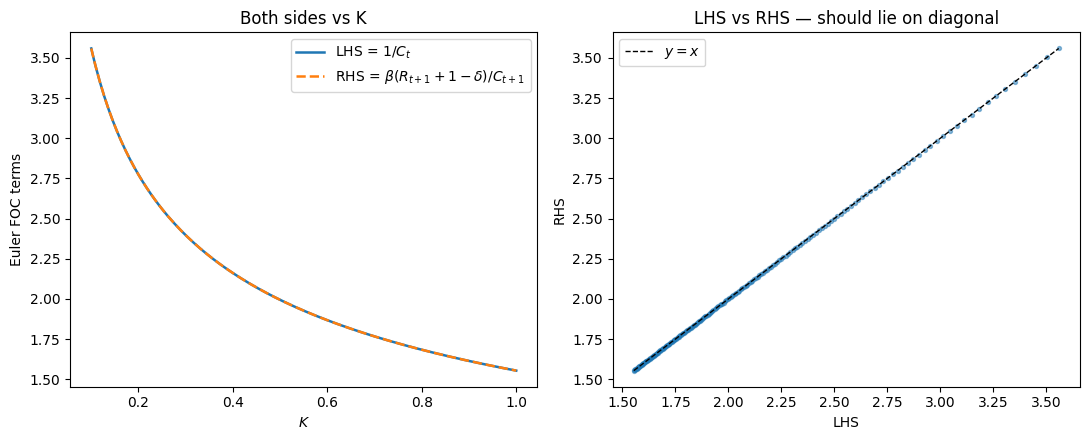

In [9]:
defs_t = definitions(states, policies, MODEL.constants)
defs_tp1 = definitions(next_states, next_policies, MODEL.constants)

c_t = np.asarray(defs_t["c"])
c_tp1 = np.asarray(defs_tp1["c"])
R_tp1 = np.asarray(defs_tp1["mpk"])
delta = MODEL.constants["delta"]

lhs = 1.0 / c_t
rhs = beta * (R_tp1 + 1 - delta) / c_tp1

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].plot(k_np, lhs, label="LHS = $1/C_t$", lw=1.8)
axes[0].plot(
    k_np, rhs, label=r"RHS = $\beta(R_{t+1}+1-\delta)/C_{t+1}$", lw=1.8, ls="--"
)
axes[0].set_xlabel("$K$")
axes[0].set_ylabel("Euler FOC terms")
axes[0].set_title("Both sides vs K")
axes[0].legend()

axes[1].scatter(lhs, rhs, s=8, alpha=0.5)
lims = [min(lhs.min(), rhs.min()), max(lhs.max(), rhs.max())]
axes[1].plot(lims, lims, "k--", lw=1, label="$y = x$")
axes[1].set_xlabel("LHS")
axes[1].set_ylabel("RHS")
axes[1].set_title("LHS vs RHS — should lie on diagonal")
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Mid-training convergence (from `cycle_hook`)

While the training call above was running, `MODEL.cycle_hook` fired every `log_every = 1000` episodes and saved a snapshot of the policy plot to `figures/bm_deterministic/`. No extra code in this notebook; the hook is declared in the model's `hooks.py` and wired through `ModelSpec.cycle_hook`.

Three snapshots at early / middle / late episodes — the oscillation shrinks as training converges on the analytic line.

episode  2000:


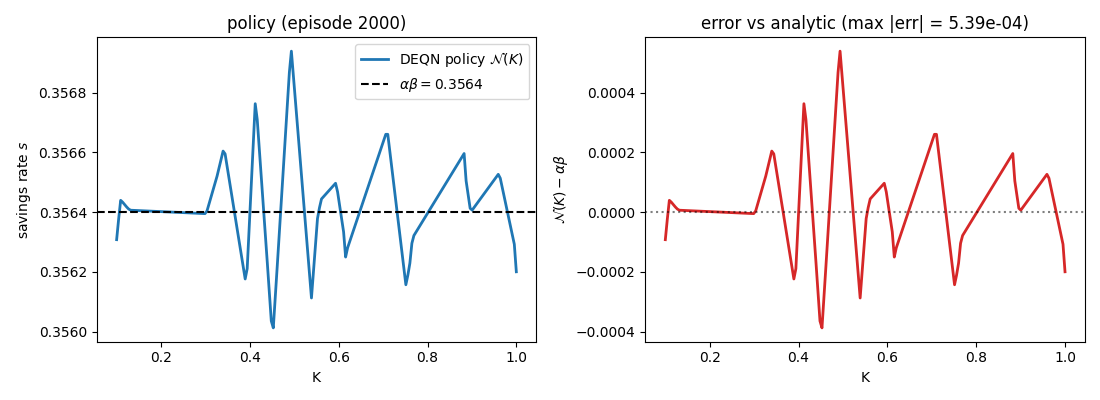

episode 10000:


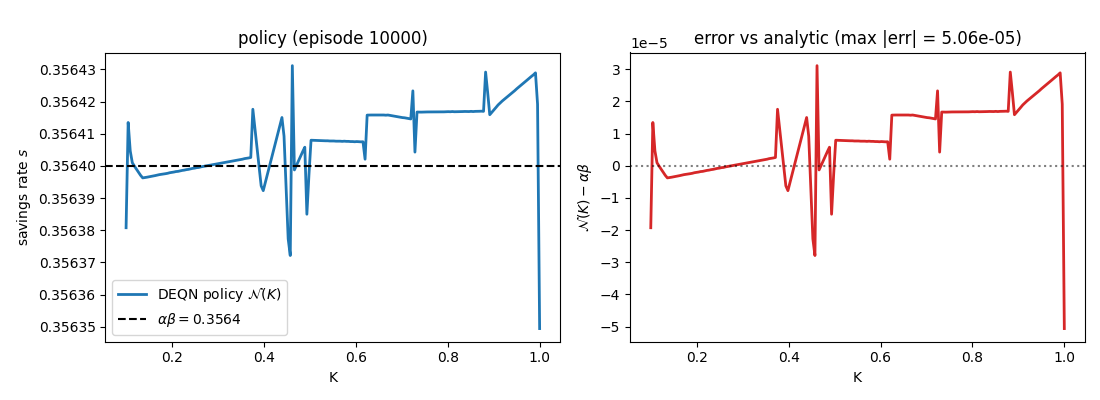

episode 20000:


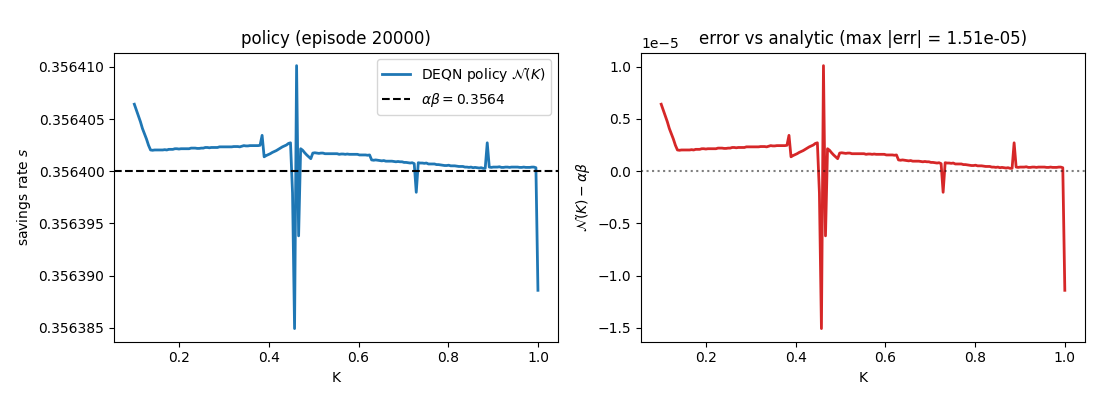

In [10]:
snapshots = [2000, 10000, 20000]
fig_dir = Path("figures/bm_deterministic")

for ep in snapshots:
    p = fig_dir / f"policy_ep{ep:05d}.png"
    if p.exists():
        print(f"episode {ep:>5}:")
        display(Image(str(p)))
    else:
        print(f"{p} missing (train the model first with the cycle_hook enabled)")

## Summary

- Trained `bm_deterministic` end-to-end with one `train_from_config` call.
- The `cycle_hook` mechanism produced convergence snapshots for free.
- All diagnostic plots above — loss curve, policy function, capital transition, Euler residual, LHS/RHS — reuse the same framework primitives (`history`, `equations_fn`, `definitions`, `plots.*`). Nothing is hand-rolled for this model.
- The trained policy matches the Brock-Mirman closed form $s^\star = \alpha\beta$ to $\sim 10^{-4}$ relative error across the full training domain.